## Decisiones de diseño
- **Imputación por mediana**: robusta a outliers y sesgos.
- **Estandarización**: imprescindible para modelos lineales y PCA.
- **Varianza > 0**: elimina columnas constantes o casi constantes.
- **Selección univariante (f_regression, ~60%)**: relación lineal útil y reduce dimensionalidad previa.
- **PCA (95%)**: compacta información.
- **Modelos**: **LightGBM** (no lineal, rápido) + **Ridge(PCA)** (estable con L2).
- **Validación por *era***: respeta temporalidad (GroupKFold por grupos) y mide estabilidad fuera de muestra.
- **CORR (Pearson) con gaussian rank**: gaussianizar reduce efecto de colas. En cambio el F1 no captura ni magnitud ni ordenación
- **Cumulative CORR, Sharpe y Max Drawdown**: evalúan consistencia y riesgo temporal, no solo el promedio.
- **Neutralización**: resta exposición a PCs (factores comunes) para ganar estabilidad por era.
- **Serialización**: reproducibilidad e inferencia consistente fuera del cuaderno.
- **Overfitting**: un sobreajuste lo que supone un riego. Por eso con PCA ayuda a recortar ese sobreajuste ya que compacta la información.

PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [113]:
# Instala dependencias
%pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
%pip install -q --no-deps numerai-tools
%pip install numerapi

# Gráficas Inline
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports

In [114]:
# === Imports mínimos adicionales para la sección de mejoras ===
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, LinearRegression
import cloudpickle as cp
import matplotlib.pyplot as plt
from numerapi import NumerAPI
import pandas as pd
import json
import lightgbm as lgb
import numpy as np
from sklearn.feature_selection import f_regression

1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [ ]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
napi = NumerAPI()

DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [116]:
# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-04 21:20:47,208 INFO numerapi.utils: target file already exists
2025-11-04 21:20:47,209 INFO numerapi.utils: download complete
2025-11-04 21:20:49,185 INFO numerapi.utils: target file already exists
2025-11-04 21:20:49,185 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


#### Comprobar si hay valores nulos dentro de train

In [117]:
# Se hace una suña de todos los nulls que hay por columna
nulls = train.isnull().sum()
print(nulls)

era                                              0
target                                           0
feature_antistrophic_striate_conscriptionist     0
feature_bicameral_showery_wallaba                0
feature_bridal_fingered_pensioner                0
feature_collectivist_flaxen_gueux                0
feature_concurring_fabled_adapter                0
feature_crosscut_whilom_ataxy                    0
feature_departmental_inimitable_sentencer        0
feature_dialectal_homely_cambodia                0
feature_donnard_groutier_twinkle                 0
feature_elusive_vapoury_accomplice               0
feature_geminate_crummiest_scourer               0
feature_glandered_unimproved_peafowl             0
feature_hempen_unionist_cone                     0
feature_illuminated_gambrel_noria                0
feature_jacobinical_symmetric_roll               0
feature_jewish_stained_disembowelment            0
feature_lacklustre_centroidal_schweitzer         0
feature_limiest_heliolithic_yor

Se puede ver que ninguna columna tiene valores nulos, asi que no es necesario haceer algun cambio en los valores

#### Numero de columnas y de filas que hay

In [118]:
print(f"Número de columnas: {train.shape[1]}", f"Número de filas: {train.shape[0]}")

Número de columnas: 44 Número de filas: 688184


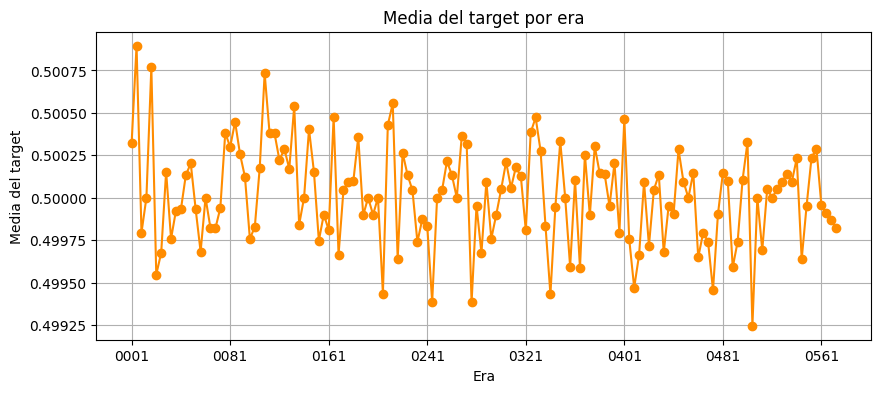

In [119]:
train.groupby("era")["target"].mean().plot(
    figsize=(10,4), marker='o', color="darkorange"
)
plt.title("Media del target por era")
plt.xlabel("Era")
plt.ylabel("Media del target")
plt.grid(True)
plt.show()


#### ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

<Axes: title={'center': 'Number of rows per era'}, xlabel='Era'>

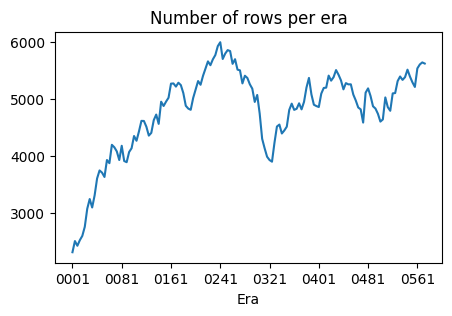

In [120]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era")

Todos los resultado de las Eras

2025-11-04 21:20:54,544 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 21:20:54,546 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 21:20:54,559 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


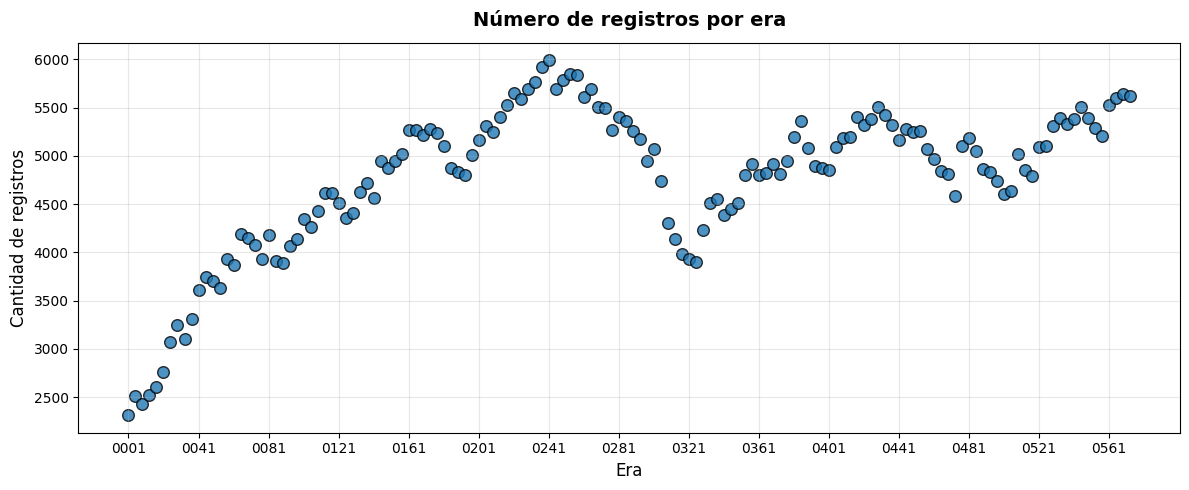

In [121]:
era_counts = train.groupby("era").size().reset_index(name="n_registros")

plt.figure(figsize=(12,5))
plt.scatter(era_counts["era"], era_counts["n_registros"], 
            color="#1f77b4", s=70, alpha=0.8, edgecolor='black')

plt.title("Número de registros por era", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Era", fontsize=12)
plt.ylabel("Cantidad de registros", fontsize=12)
plt.grid(alpha=0.3)

# Muestra una etiqueta cada 10 eras (ajusta el número según necesites)
plt.xticks(era_counts["era"][::10])

plt.tight_layout()
plt.show()


Las top 10 eras con menos registros

In [122]:
# Top 10 eras con más registros
topEra = train["era"].value_counts().head(10).index.tolist()
print (topEra)

['0241', '0237', '0253', '0257', '0249', '0233', '0245', '0265', '0229', '0221']


2025-11-04 21:20:54,771 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 21:20:54,772 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


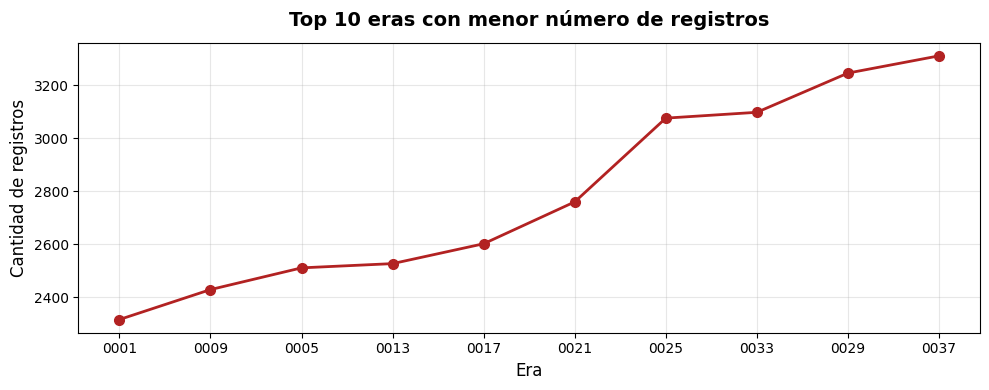

In [123]:
era_counts = train.groupby("era").size().sort_values(ascending=True).head(10).reset_index()
era_counts.columns = ["era", "n_registros"]

# Figura
plt.figure(figsize=(10, 4))

# Línea suave y puntos marcados
plt.plot(era_counts["era"], era_counts["n_registros"], 
        color="firebrick", linewidth=2, marker="o", markersize=7, label="Nº de registros")

# Personalización visual
plt.title("Top 10 eras con menor número de registros", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Era", fontsize=12)
plt.ylabel("Cantidad de registros", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [124]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


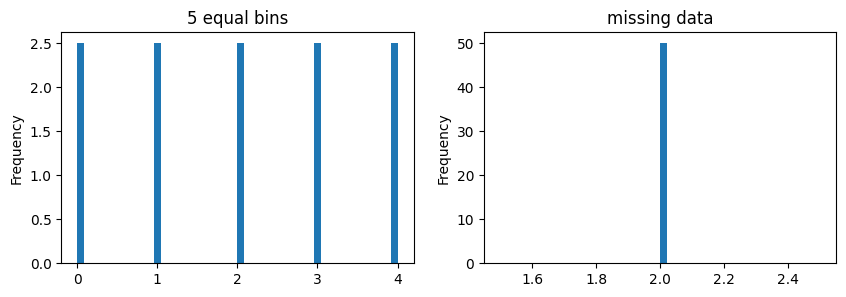

In [125]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

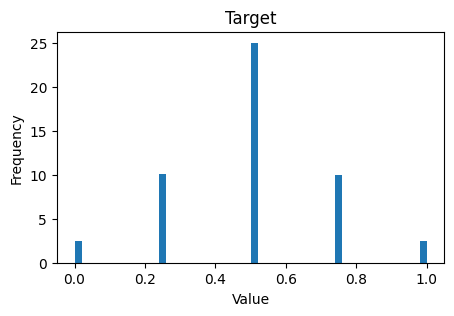

In [126]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

2.- MODELING

Entrenamiento del modelo:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [127]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [128]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

2025-11-04 21:21:18,842 INFO numerapi.utils: target file already exists
2025-11-04 21:21:18,843 INFO numerapi.utils: download complete


,era,prediction,target
id,,,
n000c290e4364875,0579,0.494547,0.50
n002a15bc5575bbb,0579,0.517560,0.25
n00309caaa0f955e,0579,0.515683,0.75
n0039cbdcf835708,0579,0.509313,0.50
n004143458984f89,0579,0.483896,0.50
...,...,...,...
nffc45fef92f9990,1183,0.500537,0.50
nffcd993886ef112,1183,0.487059,0.25
nffd2f8483ddb3cc,1183,0.512208,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [129]:
# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\afaja\AppData\Local\Temp\ipykernel_13148\38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


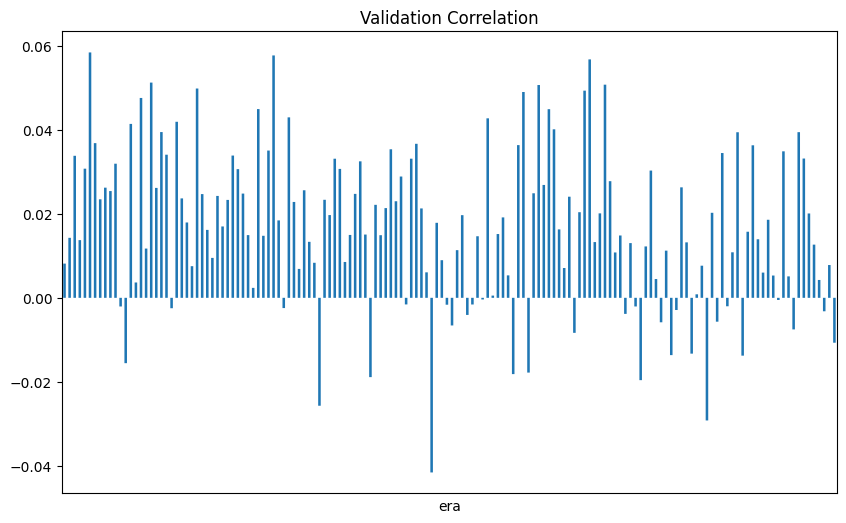

In [130]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

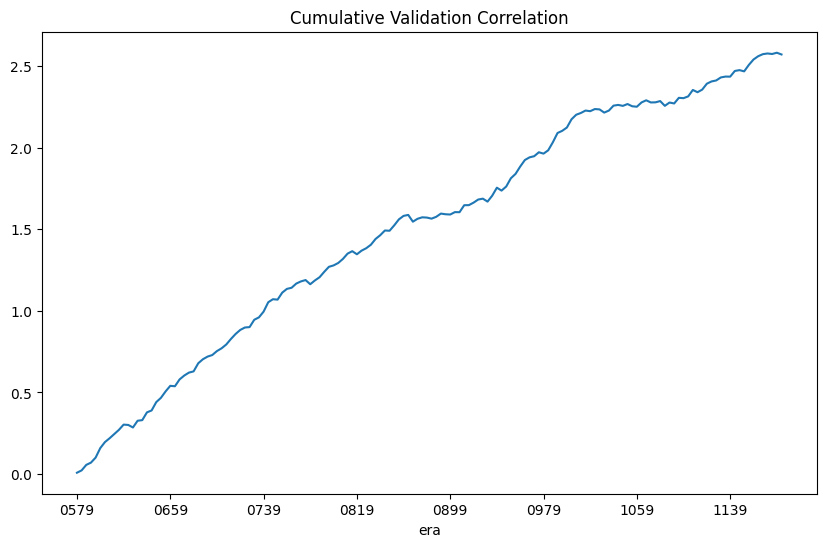

In [131]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [132]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.016923
std,0.018835
sharpe,0.898501
max_drawdown,0.041581


Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [133]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 21:21:53,343 INFO numerapi.utils: target file already exists
2025-11-04 21:21:53,345 INFO numerapi.utils: download complete


,prediction
id,
n00033945c89dc2a,0.504489
n000da32a2de4eb4,0.496172
n0010d47e977cc92,0.509463
n001d6e7f5876c97,0.492819
n002864576a9ecb2,0.508515
...,...
nffc3cc2110aea62,0.507681
nffe2b5eb838a44d,0.507715
nffe32840bab2a91,0.502967


# Mejoras


In [134]:
imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

Xtr_imp = imputer.fit_transform(train[feature_set])
Xva_imp = imputer.transform(validation[feature_set])
Xtr = scaler.fit_transform(Xtr_imp)
Xva = scaler.transform(Xva_imp)

ytr = train["target"].values
yva = validation["target"].values

In [135]:
vt = VarianceThreshold(threshold=1e-4)
Xtr_v = vt.fit_transform(Xtr)
Xva_v = vt.transform(Xva)
feat_kept_mask = vt.get_support()
feat_kept = [f for f, k in zip(feature_set, feat_kept_mask) if k]

f_scores, _ = f_regression(Xtr_v, ytr)
k = max(10, int(0.60 * len(f_scores)))
idx_top = np.argsort(f_scores)[-k:]
idx_top = np.asarray(idx_top, dtype=int).ravel()

In [136]:
Xtr_fs = Xtr_v[:, idx_top]
Xva_fs = Xva_v[:, idx_top]
feat_final = list(np.asarray(feat_kept, dtype=object)[idx_top])

pca = PCA(n_components=0.95, svd_solver="full", random_state=42)
Xtr_pca = pca.fit_transform(Xtr_fs)
Xva_pca = pca.transform(Xva_fs)

print(f"PCA -> componentes: {pca.n_components_} | varianza: {pca.explained_variance_ratio_.sum():.3f}")


PCA -> componentes: 22 | varianza: 0.962


In [137]:

eras_groups = train["era"].values
gkf = GroupKFold(n_splits=5)
alphas = [0.1, 0.3, 1.0, 3.0, 10.0]

best_alpha = None
best_cv_mean = -9

for a in alphas:
    cv_corrs = []
    for tr_idx, va_idx in gkf.split(Xtr_pca, ytr, groups=eras_groups):
        m = Ridge(alpha=a, random_state=42).fit(Xtr_pca[tr_idx], ytr[tr_idx])
        preds = m.predict(Xtr_pca[va_idx])

        r = (pd.Series(preds).rank(method="average").values - 0.5) / len(preds)
        g = stats.norm.ppf(r)
        t = ytr[va_idx] - np.mean(ytr[va_idx])
        p15 = np.sign(g) * np.abs(g)**1.5
        t15 = np.sign(t) * np.abs(t)**1.5
        corr_val = np.corrcoef(p15, t15)[0, 1]

        cv_corrs.append(corr_val)
    cv_mean = float(np.mean(cv_corrs))
    if cv_mean > best_cv_mean:
        best_cv_mean = cv_mean
        best_alpha = a

print(f"Ridge seleccionado: alpha={best_alpha} | CORR-CV(era)={best_cv_mean:.4f}")

Ridge seleccionado: alpha=10.0 | CORR-CV(era)=0.0274


In [138]:
ridge = Ridge(alpha=best_alpha, random_state=42).fit(Xtr_pca, ytr)
pred_val_ridge = ridge.predict(Xva_pca)

eras_val = pd.Index(np.unique(validation["era"]))
corr_por_era = pd.Series(index=eras_val, dtype=float)

for e in eras_val:
    mask_e = (validation["era"] == e).values
    preds_e = pred_val_ridge[mask_e]
    targ_e  = validation.loc[mask_e, "target"].values

    r_e = (pd.Series(preds_e).rank(method="average").values - 0.5) / len(preds_e)
    g_e = stats.norm.ppf(r_e)
    t_e = targ_e - np.mean(targ_e)
    p15_e = np.sign(g_e) * np.abs(g_e)**1.5
    t15_e = np.sign(t_e) * np.abs(t_e)**1.5
    corr_e = np.corrcoef(p15_e, t15_e)[0, 1]

    corr_por_era.loc[e] = corr_e

corr_mean = float(corr_por_era.mean())
corr_std  = float(corr_por_era.std(ddof=0))
corr_sharpe = float(corr_mean / (corr_std + 1e-12))
cum = corr_por_era.cumsum()
max_drawdown = float((cum.expanding(1).max() - cum).max())

print(f"Validation CORR mean={corr_mean:.4f} | std={corr_std:.4f} | Sharpe={corr_sharpe:.3f} | MaxDD={max_drawdown:.4f}")


Validation CORR mean=0.0105 | std=0.0169 | Sharpe=0.618 | MaxDD=0.0434


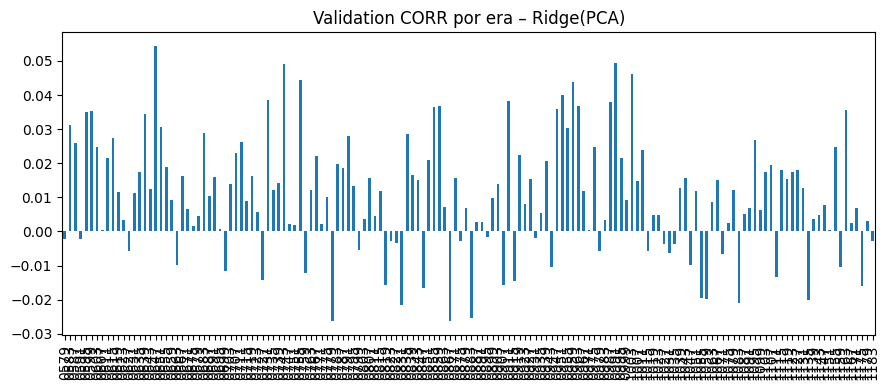

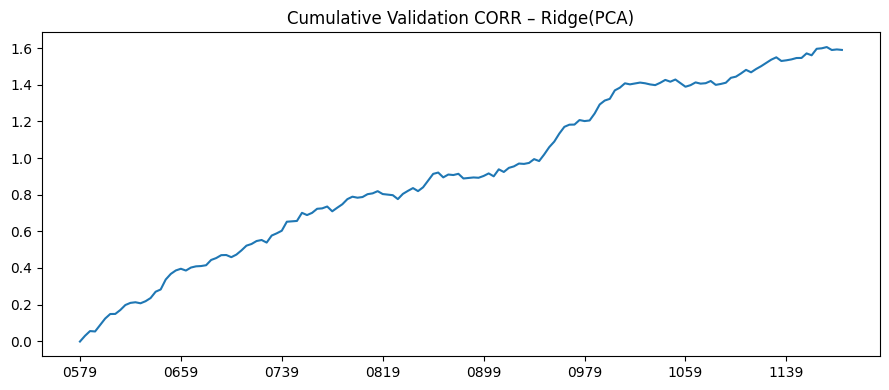

,mean,std,sharpe,max_drawdown
Ridge(PCA),0.010464,0.016940,0.617726,0.043397
LGBM(ref),0.016923,0.018835,0.898501,0.041581


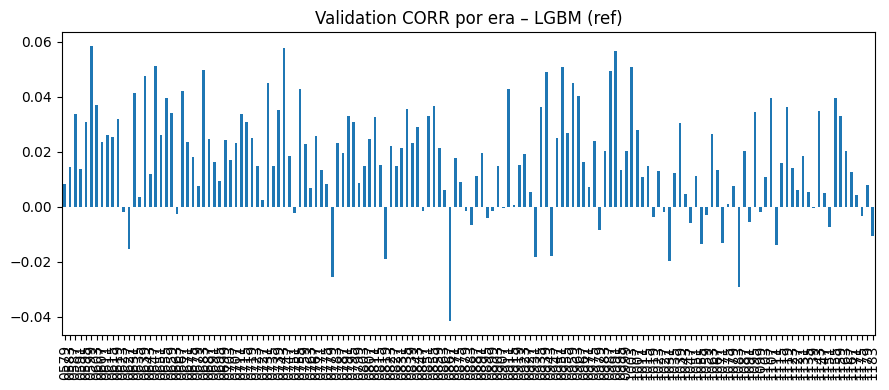

In [ ]:

corr_por_era.plot(kind='bar', figsize=(9,4), title='Validation CORR por era'); plt.tight_layout(); plt.show()
cum.plot(kind='line', figsize=(9,4), title='Cumulative Validation CORR'); plt.tight_layout(); plt.show()

if 'prediction' in validation.columns:
    corr_lgb = pd.Series(index=eras_val, dtype=float)
    for e in eras_val:
        mask_e = (validation['era'] == e).values
        preds_e = validation.loc[mask_e, 'prediction'].values
        targ_e  = validation.loc[mask_e, 'target'].values

        r_e = (pd.Series(preds_e).rank(method='average').values - 0.5) / len(preds_e)
        g_e = stats.norm.ppf(r_e)
        t_e = targ_e - np.mean(targ_e)
        p15_e = np.sign(g_e) * np.abs(g_e)**1.5
        t15_e = np.sign(t_e) * np.abs(t_e)**1.5
        corr_e = np.corrcoef(p15_e, t15_e)[0, 1]

        corr_lgb.loc[e] = corr_e

    m1 = float(corr_lgb.mean()); s1 = float(corr_lgb.std(ddof=0)); sh1 = float(m1/(s1+1e-12))
    c1 = corr_lgb.cumsum(); dd1 = float((c1.expanding(1).max() - c1).max())

    m2 = float(corr_por_era.mean()); s2 = float(corr_por_era.std(ddof=0)); sh2 = float(m2/(s2+1e-12))
    c2 = corr_por_era.cumsum(); dd2 = float((c2.expanding(1).max() - c2).max())

    resumen = pd.DataFrame({'mean':[m2,m1],'std':[s2,s1],'sharpe':[sh2,sh1],'max_drawdown':[dd2,dd1]}, index=['Ridge(PCA)','LGBM(ref)'])
    display(resumen)

    corr_lgb.plot(kind='bar', figsize=(9,4), title='Validation CORR por era'); plt.tight_layout(); plt.show()
